# Day 05 — Autograd & Computation Graphs

> **Goal:** Understand how PyTorch automatically computes gradients — the engine behind training.

## Why Gradients Matter

A **gradient** tells you: *if I change this weight a little, how does the loss change?*

- Positive gradient → increasing weight increases loss → we should decrease the weight
- Negative gradient → increasing weight decreases loss → we should increase the weight
- Zero gradient → we're at a minimum (or saddle point)

PyTorch's **autograd** computes all gradients automatically. You never need to do calculus by hand!

In [1]:
import torch
import matplotlib.pyplot as plt

## 1. `requires_grad=True` — Tell PyTorch to Track Operations

In [2]:
# A normal tensor — PyTorch does NOT track operations
x = torch.tensor(3.0)
print(f"x requires_grad: {x.requires_grad}")  # False

# A tensor with requires_grad=True — PyTorch RECORDS every operation
w = torch.tensor(2.0, requires_grad=True)
print(f"w requires_grad: {w.requires_grad}")  # True

# When we do math with w, PyTorch builds a computation graph
y = w * x + 1
print(f"\ny = w * x + 1 = {y.item()}")  # 2*3 + 1 = 7
print(f"y.grad_fn: {y.grad_fn}")  # Shows the operation that created y

x requires_grad: False
w requires_grad: True

y = w * x + 1 = 7.0
y.grad_fn: <AddBackward0 object at 0x11308c220>


## 2. `.backward()` — Compute Gradients

Calling `.backward()` on a scalar walks **backward** through the computation graph and fills in `.grad` for every tensor that has `requires_grad=True`.

For `y = w * x + 1`:
- `dy/dw = x = 3.0`

In [4]:
# Before backward: no gradients yet
print(f"w.grad before backward: {w.grad}")

# Compute gradients
y.backward()

# Now w.grad is filled in!
print(f"w.grad after backward: {w.grad}")  # 3.0 (= dy/dw = x)
print(f"Expected dy/dw = x = {x.item()}")  # Matches!

w.grad before backward: None
w.grad after backward: 3.0
Expected dy/dw = x = 3.0


## 3. The Computation Graph — Visualized

Let's trace through a more complex example step by step.

In [8]:
# Fresh tensors (gradients don't carry over)
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

# Build computation graph
c = a * b          # c = 6
d = c + a          # d = 6 + 2 = 8  
e = d ** 2          # e = 64

print("Computation graph:")
print(f"  a = {a.item()}, b = {b.item()}")
print(f"  c = a * b = {c.item()}")
print(f"  d = c + a = {d.item()}")
print(f"  e = d²    = {e.item()}")

# Backprop from e
e.backward()

# Chain rule:
# de/dd = 2d = 16
# dd/dc = 1, dd/da = 1
# dc/da = b = 3, dc/db = a = 2
# de/da = de/dd * (dd/dc * dc/da + dd/da) = 16 * (1*3 + 1) = 64
# de/db = de/dd * dd/dc * dc/db = 16 * 1 * 2 = 32

print(f"\n  de/da = {a.grad}  (expected: {2*(a.item()*b.item()+a.item()) * (b.item()+1)})")
print(f"  de/db = {b.grad}  (expected: {2*(a.item()*b.item()+a.item()) * a.item()})")
print("  ✅ Autograd matches manual chain rule!")

Computation graph:
  a = 2.0, b = 3.0
  c = a * b = 6.0
  d = c + a = 8.0
  e = d²    = 64.0

  de/da = 64.0  (expected: 64.0)
  de/db = 32.0  (expected: 32.0)
  ✅ Autograd matches manual chain rule!


## 4. `torch.no_grad()` — Stop Tracking

During inference (making predictions) or when updating weights, we don't want to track operations.

This saves memory and computation.

In [5]:
w = torch.tensor(5.0, requires_grad=True)

# With tracking (default)
y = w * 2
print(f"With grad tracking: y.requires_grad = {y.requires_grad}")
print(f"  y.grad_fn = {y.grad_fn}")

# Without tracking
with torch.no_grad():
    y_no_grad = w * 2
    print(f"\nWithout grad tracking: y.requires_grad = {y_no_grad.requires_grad}")
    print(f"  y.grad_fn = {y_no_grad.grad_fn}")  # None!

# .detach() — another way to stop tracking
y_detached = w.detach()
print(f"\nDetached: requires_grad = {y_detached.requires_grad}")

With grad tracking: y.requires_grad = True
  y.grad_fn = <MulBackward0 object at 0x118f7b190>

Without grad tracking: y.requires_grad = False
  y.grad_fn = None

Detached: requires_grad = False


## 5. Gradients Accumulate!

**Critical gotcha:** By default, calling `.backward()` **adds** to existing gradients instead of replacing them.

This is why you must call `optimizer.zero_grad()` (or `.grad.zero_()`) before each backward pass.

In [9]:
w = torch.tensor(3.0, requires_grad=True)

# First backward pass
y1 = w * 2
y1.backward()
print(f"After 1st backward: w.grad = {w.grad}")  # 2.0

# Second backward pass WITHOUT zeroing
y2 = w * 2
y2.backward()
print(f"After 2nd backward: w.grad = {w.grad}")  # 4.0! (accumulated: 2 + 2)

# Zero the gradient
w.grad.zero_()
print(f"After zero_(): w.grad = {w.grad}")  # 0.0

# Now backward gives the correct gradient
y3 = w * 2
y3.backward()
print(f"After zeroed backward: w.grad = {w.grad}")  # 2.0 ✓

After 1st backward: w.grad = 2.0
After 2nd backward: w.grad = 4.0
After zero_(): w.grad = 0.0
After zeroed backward: w.grad = 2.0


## 6. Practical Example: Gradient of a Loss Function

Let's compute the gradient of MSE loss with respect to a weight — this is exactly what happens during training.

In [10]:
torch.manual_seed(42)

# Data
X = torch.tensor([1.0, 2.0, 3.0, 4.0])
y_true = torch.tensor([2.0, 4.0, 6.0, 8.0])  # y = 2x

# Learnable parameters
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# Forward pass
y_pred = w * X + b

# Loss (MSE)
loss = ((y_pred - y_true) ** 2).mean()
print(f"Predictions: {y_pred.data}")
print(f"Loss: {loss.item():.4f}")

# Backward pass
loss.backward()

print(f"\n∂loss/∂w = {w.grad:.4f}")
print(f"∂loss/∂b = {b.grad:.4f}")
print("\nBoth gradients are negative → we should INCREASE w and b to reduce loss.")

Predictions: tensor([0., 0., 0., 0.])
Loss: 30.0000

∂loss/∂w = -30.0000
∂loss/∂b = -10.0000

Both gradients are negative → we should INCREASE w and b to reduce loss.


## 7. Visualize: The Gradient Points Downhill

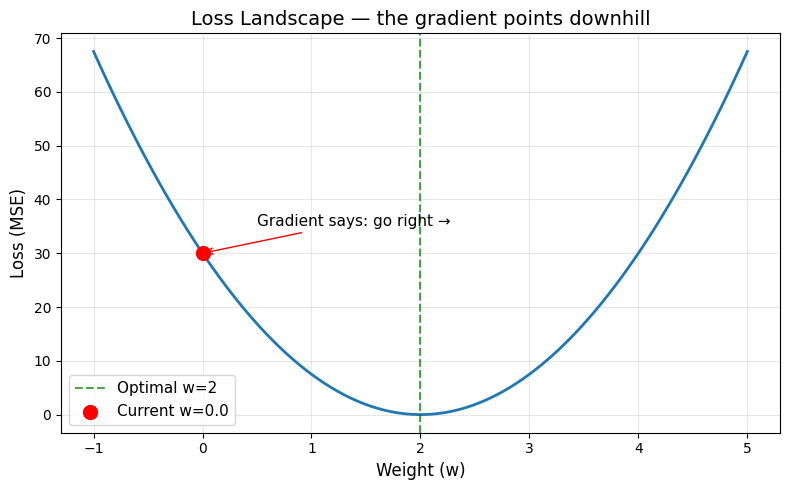

In [7]:
# Let's visualize loss as a function of w (with b=0)
w_values = torch.linspace(-1, 5, 100)
losses = []

for w_val in w_values:
    y_pred = w_val * X  # b=0
    loss_val = ((y_pred - y_true) ** 2).mean()
    losses.append(loss_val.item())

plt.figure(figsize=(8, 5))
plt.plot(w_values.numpy(), losses, linewidth=2)
plt.xlabel("Weight (w)", fontsize=12)
plt.ylabel("Loss (MSE)", fontsize=12)
plt.title("Loss Landscape — the gradient points downhill", fontsize=14)
plt.axvline(x=2.0, color="green", linestyle="--", alpha=0.7, label="Optimal w=2")

# Mark current position and gradient direction
w_current = 0.0
loss_current = ((w_current * X - y_true) ** 2).mean().item()
plt.scatter([w_current], [loss_current], color="red", s=100, zorder=5, label=f"Current w={w_current}")
plt.annotate("Gradient says: go right →", xy=(w_current, loss_current),
             xytext=(0.5, loss_current+5), fontsize=11,
             arrowprops=dict(arrowstyle="->", color="red"))

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## ✏️ Exercises

In [ ]:
# Exercise 1: Compute the gradient of f(x) = x³ + 2x² - 5x + 3 at x=2
# Steps: create tensor x with requires_grad, compute f, call backward, check x.grad
# Verify: f'(x) = 3x² + 4x - 5, so f'(2) = 12 + 8 - 5 = 15

# Your code here:

In [ ]:
# Exercise 2: Create two parameters w1 and w2 (requires_grad=True).
# Compute y = w1 * w2 + w1² and get gradients of y w.r.t. both.
# Verify by hand: dy/dw1 = w2 + 2*w1, dy/dw2 = w1

# Your code here:

---
## 📝 Key Takeaways

1. **`requires_grad=True`** → PyTorch tracks all operations on this tensor.
2. **`.backward()`** → computes all gradients via chain rule (backpropagation).
3. **`.grad`** → contains the computed gradient after `.backward()`.
4. **Gradients accumulate!** → Always zero them before the next `.backward()`.
5. **`torch.no_grad()`** → use during inference to save memory.
6. The gradient of a loss w.r.t. a weight tells you **which direction to adjust the weight**.

**Tomorrow:** We'll use these gradients to implement gradient descent from scratch!